In [1]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [2]:
!pip install -q pandas numpy matplotlib seaborn scikit-learn torch torchvision torchaudio tqdm pyyaml

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
import os

folders = [
    "data",
    "src",
    "models",
    "results",
    "results/figures",
    "results/metrics",
    "results/checkpoints"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Project folders created.")

Project folders created.


In [3]:
!find . -maxdepth 2 -type d

.
./.config
./.config/logs
./.config/configurations
./models
./data
./src
./results
./results/metrics
./results/checkpoints
./results/figures
./sample_data


In [1]:
!pip install -q -U kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 6.4 MB/s eta 0:00:00


In [2]:
!kaggle --version

Kaggle CLI 2.2.4


In [3]:
!kaggle auth login


Go to the following link in your browser, and complete the sign-in prompts at Kaggle:

  https://www.kaggle.com/api/v1/oauth2/authorize?response_type=code&client_id=kagglesdk&redirect_uri=https%3A%2F%2Fwww.kaggle.com%2Faccount%2Fapi%2Foauth%2Ftoken&scope=resources.admin%3A%2A&state=688ce533-7724-4bc9-8462-7a84dc69f343&code_challenge=qLy8Q5ZlW0reinU74mVAz9Vy91_qgttoaPh5qW0OkHI%3D&code_challenge_method=S256&response_mode=query

Once finished, enter the verification code provided in your browser: CfDJ8OasvsPNS7VMiSwiBm2YVpOFj_yzlMuWM4fqintcycjMMA2lE5pVNyNgpAe3qwLUQm2ABbsvllfoSu4mtrAB6FpVdo4hg_ds1G5YzvpTAlHR_s0DmZ_Jd3A6mr2mtJStt2gUTYNTW9KEHCY53_TXEINqRGbd6Ner58Tdf_4MnSmGicVMTFF_jCuUY2-lmCoOPjtrFD6Q64XbOzQHTe0qPs3e30JXUjBf7FyVr0n7SZgxb0w5CZV21D_Rj6wxxGsPhW4VGheK6DELh4QeeMcihZ6D47MQmvwmYINFM4QscBT3qM02LvLJhg2N-m5zipgecOtqz9_nehDGuVVW1I3TuoSMrb2-jlo

You are now logged in as [navi203]



In [4]:
!kaggle datasets list -s "m5 forecasting"

ref                                                  title                                          size  lastUpdated                 downloadCount  voteCount  usabilityRating  
---------------------------------------------------  ---------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
kyakovlev/m5-aux-models                              M5 - AUX models                           409480405  2020-04-17 09:58:24.367000           2169         57                1  
jpmiller/publicassistance                            US Public Food Assistance 1 - WIC            304041  2023-04-17 20:01:05.960000          35339        525        0.9411765  
headsortails/us-natural-disaster-declarations        US Natural Disaster Declarations            4469056  2025-11-11 20:29:44.193000           7051        153                1  
tbierhance/m5-forecasting-parquet-and-aggregations   M5 Forecasting Parquet and Aggregations    76399626  2021

In [5]:
!mkdir -p /content/data/m5

In [6]:
!kaggle competitions download -c m5-forecasting-accuracy -p /content/data/m5

100% 45.8M/45.8M [00:00<00:00, 83.3MB/s]



In [7]:
!ls -lh /content/data/m5

total 46M
-rw-r--r-- 1 root root 46M Jun  1  2020 m5-forecasting-accuracy.zip


In [8]:
!unzip -q /content/data/m5/m5-forecasting-accuracy.zip \
    -d /content/data/m5/extracted

In [9]:
!ls -lh /content/data/m5/extracted

total 430M
-rw-r--r-- 1 root root 102K Jun  1  2020 calendar.csv
-rw-r--r-- 1 root root 117M Jun  1  2020 sales_train_evaluation.csv
-rw-r--r-- 1 root root 115M Jun  1  2020 sales_train_validation.csv
-rw-r--r-- 1 root root 5.0M Jun  1  2020 sample_submission.csv
-rw-r--r-- 1 root root 194M Jun  1  2020 sell_prices.csv


In [10]:
import pandas as pd

data_path = "/content/data/m5/extracted"

calendar = pd.read_csv(
    f"{data_path}/calendar.csv"
)

prices = pd.read_csv(
    f"{data_path}/sell_prices.csv"
)

sales = pd.read_csv(
    f"{data_path}/sales_train_validation.csv"
)

print("Calendar:", calendar.shape)
print("Prices:", prices.shape)
print("Sales:", sales.shape)

Calendar: (1969, 14)
Prices: (6841121, 4)
Sales: (30490, 1919)


In [11]:
calendar.head()

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1


In [12]:
sales.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,3,0,1,1,1,3,0,1,1
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,2,1,1,1,0,1,1,1
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,5,4,1,0,1,3,7,2
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,1,0,1,1,2,2,2,4


In [13]:
prices.head()

,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26


In [14]:
print("===== DATASET SHAPES =====")
print(f"Calendar: {calendar.shape}")
print(f"Sell prices: {prices.shape}")
print(f"Sales: {sales.shape}")


===== DATASET SHAPES =====
Calendar: (1969, 14)
Sell prices: (6841121, 4)
Sales: (30490, 1919)


In [15]:
calendar.head()

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1


In [16]:
calendar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1969 entries, 0 to 1968
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   date          1969 non-null   object
 1   wm_yr_wk      1969 non-null   int64 
 2   weekday       1969 non-null   object
 3   wday          1969 non-null   int64 
 4   month         1969 non-null   int64 
 5   year          1969 non-null   int64 
 6   d             1969 non-null   object
 7   event_name_1  162 non-null    object
 8   event_type_1  162 non-null    object
 9   event_name_2  5 non-null      object
 10  event_type_2  5 non-null      object
 11  snap_CA       1969 non-null   int64 
 12  snap_TX       1969 non-null   int64 
 13  snap_WI       1969 non-null   int64 
dtypes: int64(7), object(7)
memory usage: 215.5+ KB


In [17]:
print("Calendar columns:")
print(calendar.columns.tolist())

Calendar columns:
['date', 'wm_yr_wk', 'weekday', 'wday', 'month', 'year', 'd', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2', 'snap_CA', 'snap_TX', 'snap_WI']


In [18]:
sales.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,3,0,1,1,1,3,0,1,1
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,2,1,1,1,0,1,1,1
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,5,4,1,0,1,3,7,2
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,1,0,1,1,2,2,2,4


In [20]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30490 entries, 0 to 30489
Columns: 1919 entries, id to d_1913
dtypes: int64(1913), object(6)
memory usage: 446.4+ MB


In [21]:
print("Number of products:", sales["item_id"].nunique())
print("Number of stores:", sales["store_id"].nunique())
print("Number of departments:", sales["dept_id"].nunique())
print("Number of categories:", sales["cat_id"].nunique())
print("Number of states:", sales["state_id"].nunique())

Number of products: 3049
Number of stores: 10
Number of departments: 7
Number of categories: 3
Number of states: 3


In [22]:
print("Unique stores:")
print(sales["store_id"].unique())

print("\nUnique states:")
print(sales["state_id"].unique())

print("\nUnique categories:")
print(sales["cat_id"].unique())

Unique stores:
['CA_1' 'CA_2' 'CA_3' 'CA_4' 'TX_1' 'TX_2' 'TX_3' 'WI_1' 'WI_2' 'WI_3']

Unique states:
['CA' 'TX' 'WI']

Unique categories:
['HOBBIES' 'HOUSEHOLD' 'FOODS']


In [23]:
sales_columns = [
    col for col in sales.columns
    if col.startswith("d_")
]

print("Number of daily sales columns:", len(sales_columns))
print("First 5:", sales_columns[:5])
print("Last 5:", sales_columns[-5:])

Number of daily sales columns: 1913
First 5: ['d_1', 'd_2', 'd_3', 'd_4', 'd_5']
Last 5: ['d_1909', 'd_1910', 'd_1911', 'd_1912', 'd_1913']


In [24]:
print("===== MISSING VALUES =====")

print("\nCalendar:")
print(calendar.isnull().sum())

print("\nPrices:")
print(prices.isnull().sum())

print("\nSales:")
print(sales.isnull().sum().sort_values(ascending=False).head(20))

===== MISSING VALUES =====

Calendar:
date               0
wm_yr_wk           0
weekday            0
wday               0
month              0
year               0
d                  0
event_name_1    1807
event_type_1    1807
event_name_2    1964
event_type_2    1964
snap_CA            0
snap_TX            0
snap_WI            0
dtype: int64

Prices:
store_id      0
item_id       0
wm_yr_wk      0
sell_price    0
dtype: int64

Sales:
d_1913      0
id          0
item_id     0
dept_id     0
cat_id      0
store_id    0
state_id    0
d_1         0
d_2         0
d_3         0
d_4         0
d_5         0
d_6         0
d_7         0
d_8         0
d_9         0
d_10        0
d_11        0
d_12        0
d_13        0
dtype: int64


In [25]:
print("Calendar duplicate rows:", calendar.duplicated().sum())
print("Prices duplicate rows:", prices.duplicated().sum())
print("Sales duplicate rows:", sales.duplicated().sum())

Calendar duplicate rows: 0
Prices duplicate rows: 0
Sales duplicate rows: 0


In [26]:
print(
    "Duplicate price keys:",
    prices.duplicated(
        subset=["store_id", "item_id", "wm_yr_wk"]
    ).sum()
)

Duplicate price keys: 0


In [27]:
sales[sales_columns].describe()

,d_1,d_2,d_3,d_4,d_5,d_6,d_7,d_8,d_9,d_10,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
count,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,...,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000
mean,1.070220,1.041292,0.780026,0.833454,0.627944,0.958052,0.918662,1.244080,1.073663,0.838701,...,1.370581,1.586159,1.693670,1.248245,1.232207,1.159167,1.149000,1.328862,1.605838,1.633158
std,5.126689,5.365468,3.667454,4.415141,3.379344,4.785947,5.059495,6.617729,5.917204,4.206199,...,3.740017,4.097191,4.359809,3.276925,3.125471,2.876026,2.950364,3.358012,4.089422,3.812248
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,2.000000
max,360.000000,436.000000,207.000000,323.000000,296.000000,314.000000,316.000000,370.000000,385.000000,353.000000,...,129.000000,160.000000,204.000000,98.000000,100.000000,88.000000,77.000000,141.000000,171.000000,130.000000


In [28]:
total_units_sold = sales[sales_columns].sum().sum()

print("Total units sold:", total_units_sold)

Total units sold: 65695409


In [29]:
print("Minimum daily unit value:", sales[sales_columns].min().min())
print("Maximum daily unit value:", sales[sales_columns].max().max())
print("Mean daily unit value:", sales[sales_columns].mean().mean())

Minimum daily unit value: 0
Maximum daily unit value: 763
Mean daily unit value: 1.126322153733316


In [30]:
daily_sales = sales[sales_columns].sum(axis=0)

print(daily_sales.head())
print(daily_sales.tail())

d_1    32631
d_2    31749
d_3    23783
d_4    25412
d_5    19146
dtype: int64
d_1909    35343
d_1910    35033
d_1911    40517
d_1912    48962
d_1913    49795
dtype: int64


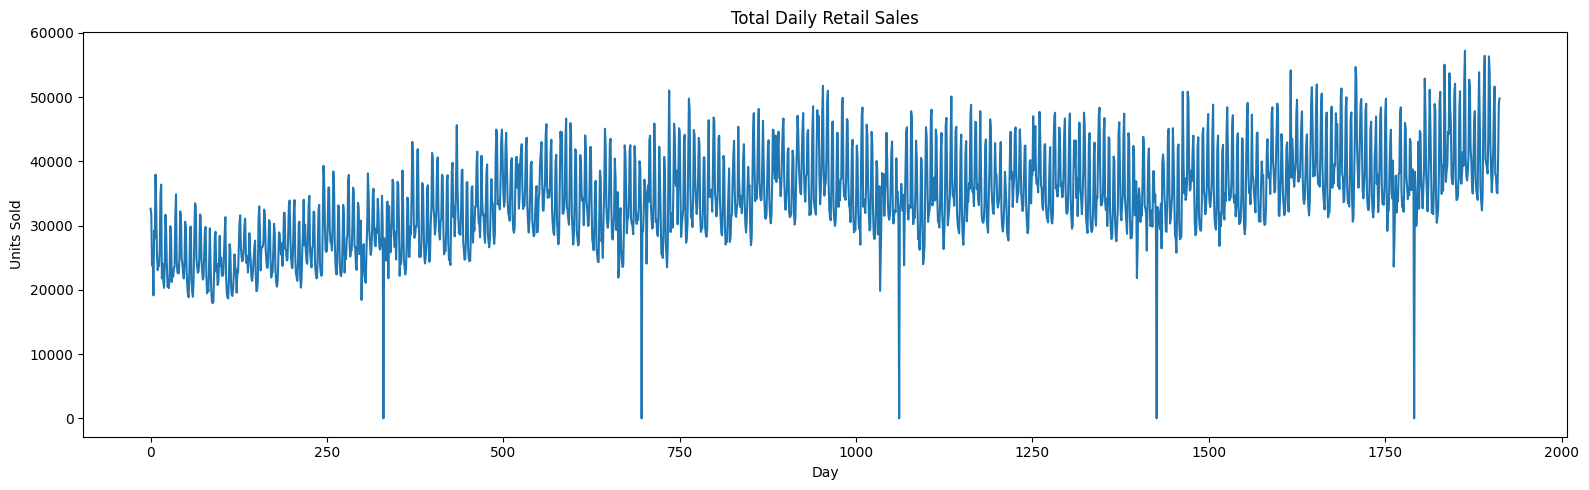

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 5))

plt.plot(
    range(len(daily_sales)),
    daily_sales.values
)

plt.title("Total Daily Retail Sales")
plt.xlabel("Day")
plt.ylabel("Units Sold")

plt.tight_layout()
plt.show()